# CODSOFT Internship - Task 2

## Exploratory Data Analysis and Business Insights

### Objective

The objective of this task is to explore an employee dataset using Python and Pandas, examine its features using descriptive statistics, identify trends and distributions, analyze relationships between variables, detect outliers and unusual patterns, and use summary statistics to answer important business questions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("cleaned_employee_data.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
df.head()

,Employee_ID,Name,Age,Gender,Department,City,Salary,Joining_Date,Experience_Years,Email,Performance_Rating
0,1,Tanvi Singh,22.0,Male,Operations,Gurugram,54256.0,2019-07-26,11,tanvi.singh1@company.com,Excellent
1,2,Vivek Mehta,26.0,Male,Sales,Lucknow,28905.0,2019-01-19,3,vivek.mehta2@company.com,Good
2,3,Rohan Patel,22.0,Other,Sales,Noida,110181.0,2025-11-12,8,rohan.patel3@company.com,Needs Improvement
3,4,Diya Negi,38.0,Male,Data Analytics,Delhi,116506.0,2022-09-28,5,diya.negi4@company.com,Average
4,5,Avni Gupta,42.0,Female,IT,Dehradun,37676.0,2022-01-10,5,avni.gupta5@company.com,Average


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 490
Columns: 11


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 490 entries, 0 to 489
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Employee_ID         490 non-null    int64  
 1   Name                490 non-null    str    
 2   Age                 490 non-null    float64
 3   Gender              490 non-null    str    
 4   Department          490 non-null    str    
 5   City                490 non-null    str    
 6   Salary              490 non-null    float64
 7   Joining_Date        490 non-null    str    
 8   Experience_Years    490 non-null    int64  
 9   Email               490 non-null    str    
 10  Performance_Rating  490 non-null    str    
dtypes: float64(2), int64(2), str(7)
memory usage: 42.2 KB


In [6]:
df.columns.tolist()

['Employee_ID',
 'Name',
 'Age',
 'Gender',
 'Department',
 'City',
 'Salary',
 'Joining_Date',
 'Experience_Years',
 'Email',
 'Performance_Rating']

## 1. Descriptive Statistics

In [7]:
df.describe()

,Employee_ID,Age,Salary,Experience_Years
count,490.00000,490.000000,490.000000,490.000000
mean,245.50000,38.136735,73935.930612,6.136735
std,141.59508,9.981971,27028.513162,3.713084
min,1.00000,21.000000,25235.000000,0.000000
25%,123.25000,29.000000,51358.000000,3.000000
50%,245.50000,39.000000,74272.000000,6.000000
75%,367.75000,46.000000,98369.750000,9.000000
max,490.00000,55.000000,119210.000000,12.000000


## 2. Distribution Analysis

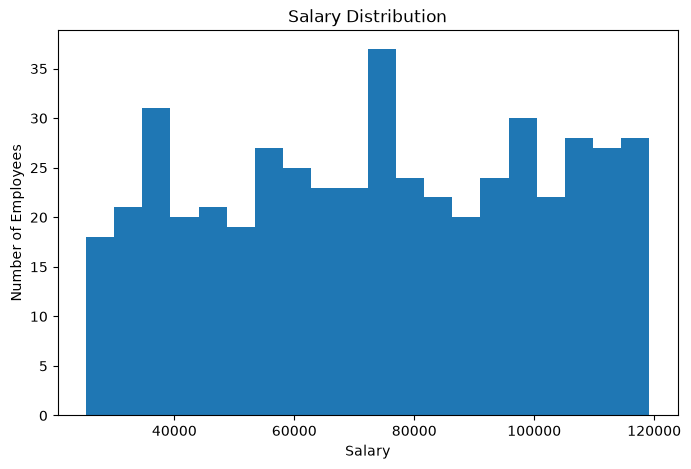

In [8]:
plt.figure(figsize=(8, 5))

plt.hist(df["Salary"], bins=20)

plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Number of Employees")

plt.show()

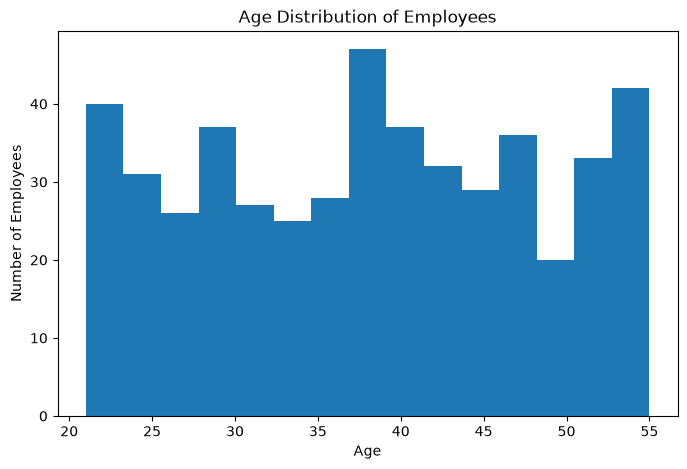

In [9]:
plt.figure(figsize=(8, 5))

plt.hist(df["Age"], bins=15)

plt.title("Age Distribution of Employees")
plt.xlabel("Age")
plt.ylabel("Number of Employees")

plt.show()

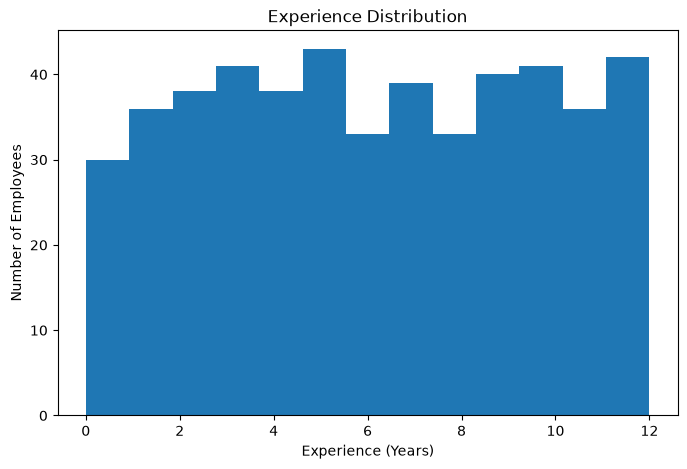

In [10]:
plt.figure(figsize=(8, 5))

plt.hist(df["Experience_Years"], bins=13)

plt.title("Experience Distribution")
plt.xlabel("Experience (Years)")
plt.ylabel("Number of Employees")

plt.show()

## 3. Department-wise Analysis

In [11]:
department_counts = df["Department"].value_counts()

department_counts

Department
Marketing         85
Sales             71
HR                68
Operations        66
IT                66
Finance           66
Data Analytics    61
Unknown            7
Name: count, dtype: int64

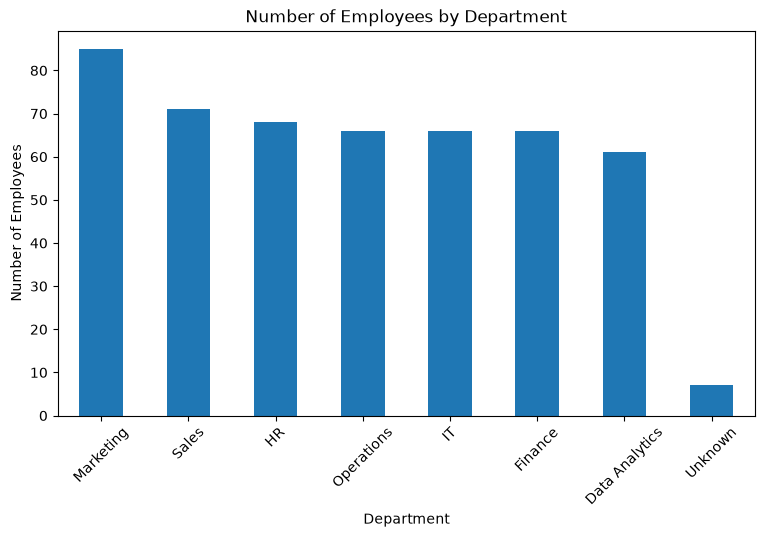

In [12]:
plt.figure(figsize=(9, 5))

department_counts.plot(kind="bar")

plt.title("Number of Employees by Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")

plt.xticks(rotation=45)

plt.show()

In [13]:
department_salary = df.groupby("Department")["Salary"].agg(
    ["count", "mean", "median", "min", "max"]
)

department_salary.sort_values("mean", ascending=False)

,count,mean,median,min,max
Department,,,,,
Unknown,7,79908.714286,92391.0,28826.0,117244.0
Operations,66,78033.045455,80341.0,25866.0,118375.0
Marketing,85,76505.070588,75968.0,27560.0,119210.0
Finance,66,73837.772727,74272.0,25336.0,115673.0
Sales,71,73792.816901,73571.0,28905.0,118365.0
Data Analytics,61,73221.573770,72013.0,27631.0,118625.0
HR,68,71355.926471,65893.5,25235.0,117801.0
IT,66,69467.136364,70357.5,26061.0,118677.0


## 4. Relationship Between Experience and Salary

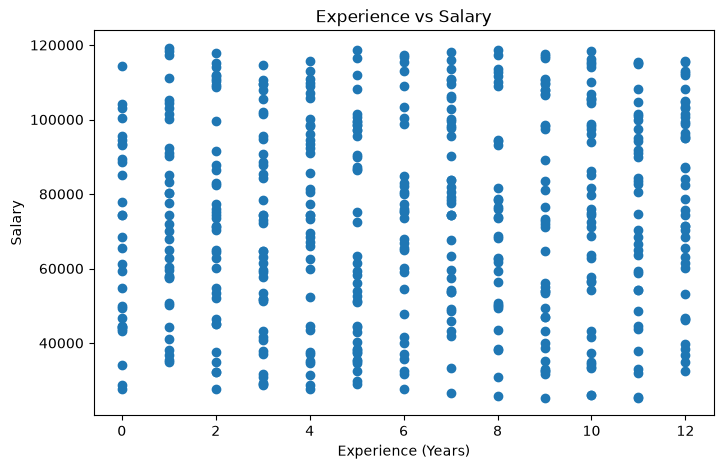

In [14]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Experience_Years"],
    df["Salary"]
)

plt.title("Experience vs Salary")
plt.xlabel("Experience (Years)")
plt.ylabel("Salary")

plt.show()

In [15]:
correlation = df["Experience_Years"].corr(df["Salary"])

print("Correlation between Experience and Salary:", correlation)

Correlation between Experience and Salary: 0.0690334807765043


## 5. Outlier Detection

In [16]:
Q1 = df["Salary"].quantile(0.25)
Q3 = df["Salary"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 51358.0
Q3: 98369.75
IQR: 47011.75
Lower Bound: -19159.625
Upper Bound: 168887.375


In [17]:
salary_outliers = df[
    (df["Salary"] < lower_bound) |
    (df["Salary"] > upper_bound)
]

print("Number of salary outliers:", len(salary_outliers))

Number of salary outliers: 0


In [18]:
salary_outliers

,Employee_ID,Name,Age,Gender,Department,City,Salary,Joining_Date,Experience_Years,Email,Performance_Rating


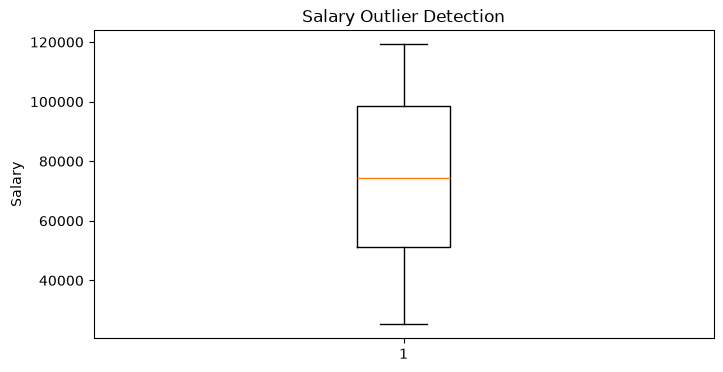

In [19]:
plt.figure(figsize=(8, 4))

plt.boxplot(df["Salary"])

plt.title("Salary Outlier Detection")
plt.ylabel("Salary")

plt.show()

In [20]:
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of salary outliers:", len(salary_outliers))

Q1: 51358.0
Q3: 98369.75
IQR: 47011.75
Lower Bound: -19159.625
Upper Bound: 168887.375
Number of salary outliers: 0


### Salary Outlier Findings

The Interquartile Range (IQR) method was used to detect potential salary outliers.

- Q1 (25th percentile): ₹51,358
- Q3 (75th percentile): ₹98,369.75
- IQR: ₹47,011.75
- Lower bound: approximately -₹19,159.63
- Upper bound: approximately ₹168,887.38
- Number of detected salary outliers: 0

The maximum salary in the dataset is ₹119,210, which is below the calculated upper outlier threshold. Therefore, no salary values were identified as statistical outliers using the IQR method.

## 6. Business Questions and Insights

## Question 1 — What is the average employee salary?

In [22]:
print("Average Salary:", df["Salary"].mean())
print("Median Salary:", df["Salary"].median())

Average Salary: 73935.9306122449
Median Salary: 74272.0


## Question 2 — Which department has the highest average salary?

In [23]:
department_avg_salary = (
    df.groupby("Department")["Salary"]
    .mean()
    .sort_values(ascending=False)
)

department_avg_salary

Department
Unknown           79908.714286
Operations        78033.045455
Marketing         76505.070588
Finance           73837.772727
Sales             73792.816901
Data Analytics    73221.573770
HR                71355.926471
IT                69467.136364
Name: Salary, dtype: float64

## Question 3 — Which department has the most employees?

In [24]:
department_employee_count = df["Department"].value_counts()

department_employee_count

Department
Marketing         85
Sales             71
HR                68
Operations        66
IT                66
Finance           66
Data Analytics    61
Unknown            7
Name: count, dtype: int64

## Question 4 — What is the average experience of employees?

In [25]:
print("Average Experience:", df["Experience_Years"].mean())
print("Median Experience:", df["Experience_Years"].median())

Average Experience: 6.136734693877551
Median Experience: 6.0


## Question 5 — Which performance rating is most common?

In [26]:
performance_counts = df["Performance_Rating"].value_counts()

performance_counts

Performance_Rating
Needs Improvement    142
Average              127
Good                 115
Excellent            106
Name: count, dtype: int64

## Question 6 — Which city has the highest number of employees?

In [27]:
city_employee_count = df["City"].value_counts()

city_employee_count

City
Dehradun      57
Jaipur        55
Gurugram      53
Chandigarh    52
Mumbai        51
Haridwar      50
Noida         47
Lucknow       43
Delhi         42
Bengaluru     40
Name: count, dtype: int64

## Question 7 — Which city has the highest average salary?

In [28]:
city_avg_salary = (
    df.groupby("City")["Salary"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

city_avg_salary

,count,mean,median
City,,,
Jaipur,55,79866.854545,83606.0
Dehradun,57,78103.403509,80255.0
Haridwar,50,77267.180000,79671.5
Lucknow,43,75522.883721,74436.0
Mumbai,51,73566.862745,76645.0
Delhi,42,73343.452381,77730.0
Chandigarh,52,73092.846154,73930.5
Bengaluru,40,72081.975000,67806.5
Gurugram,53,67624.566038,62567.0


## Question 8 — Does performance rating relate to salary?

In [29]:
performance_salary = (
    df.groupby("Performance_Rating")["Salary"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)

performance_salary

,count,mean,median,min,max
Performance_Rating,,,,,
Good,115,75365.643478,77581.0,25540.0,118677.0
Average,127,74406.322835,74272.0,25336.0,119210.0
Needs Improvement,142,73197.133803,74272.0,25235.0,117459.0
Excellent,106,72810.952830,72794.5,26061.0,118375.0


## Question 9 — Which experience group has the highest average salary?

In [30]:
df["Experience_Group"] = pd.cut(
    df["Experience_Years"],
    bins=[-1, 2, 5, 8, 12],
    labels=["0-2 Years", "3-5 Years", "6-8 Years", "9-12 Years"]
)

In [31]:
experience_salary = (
    df.groupby("Experience_Group", observed=False)["Salary"]
    .agg(["count", "mean", "median"])
)

experience_salary

,count,mean,median
Experience_Group,,,
0-2 Years,104,73032.961538,72723.5
3-5 Years,122,70960.073770,72330.0
6-8 Years,105,75109.038095,75335.0
9-12 Years,159,76035.220126,75968.0


## Question 10 — What percentage of employees are in each department?

In [32]:
department_percentage = (
    df["Department"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

department_percentage

Department
Marketing         17.35
Sales             14.49
HR                13.88
Operations        13.47
IT                13.47
Finance           13.47
Data Analytics    12.45
Unknown            1.43
Name: proportion, dtype: float64

## Question 11 — Which department has the highest salary variation?

In [33]:
department_salary_variation = (
    df.groupby("Department")["Salary"]
    .agg(["count", "mean", "std", "min", "max"])
    .sort_values("std", ascending=False)
)

department_salary_variation

,count,mean,std,min,max
Department,,,,,
Unknown,7,79908.714286,34036.361717,28826.0,117244.0
Finance,66,73837.772727,28607.915964,25336.0,115673.0
Data Analytics,61,73221.573770,27715.297355,27631.0,118625.0
HR,68,71355.926471,27517.953833,25235.0,117801.0
Marketing,85,76505.070588,27337.906091,27560.0,119210.0
Sales,71,73792.816901,26899.859748,28905.0,118365.0
IT,66,69467.136364,26701.574557,26061.0,118677.0
Operations,66,78033.045455,23783.342659,25866.0,118375.0
